In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded!")

Libraries loaded!


In [25]:
print("\nDownloading dataset from Kaggle...")

try:
    import kagglehub
except ImportError:
    print("Installing kagglehub...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'kagglehub', '-q'])
    import kagglehub

path = kagglehub.dataset_download('nalisha/tesla-ea-deliveries-and-production-data20152025')
csv_file = os.path.join(path, 'tesla_deliveries_dataset_2015_2025.csv')
df = pd.read_csv(csv_file)

print(f"Dataset loaded successfully!")
print("\n")
print("TESLA PRODUCTION FORECASTING PIPELINE:-" + "\n")
print(f"\nDataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")
print(f"Regions: {df['Region'].nunique()}")
print(f"Models: {df['Model'].nunique()}")


Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Dataset loaded successfully!


TESLA PRODUCTION FORECASTING PIPELINE:-


Dataset: 2640 rows, 12 columns
Years: 2015 - 2025
Regions: 4
Models: 5


Exploratory Data Analysis (EDA):-

Missing values: 0
Duplicates: 0

Numerical columns stats:
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std   

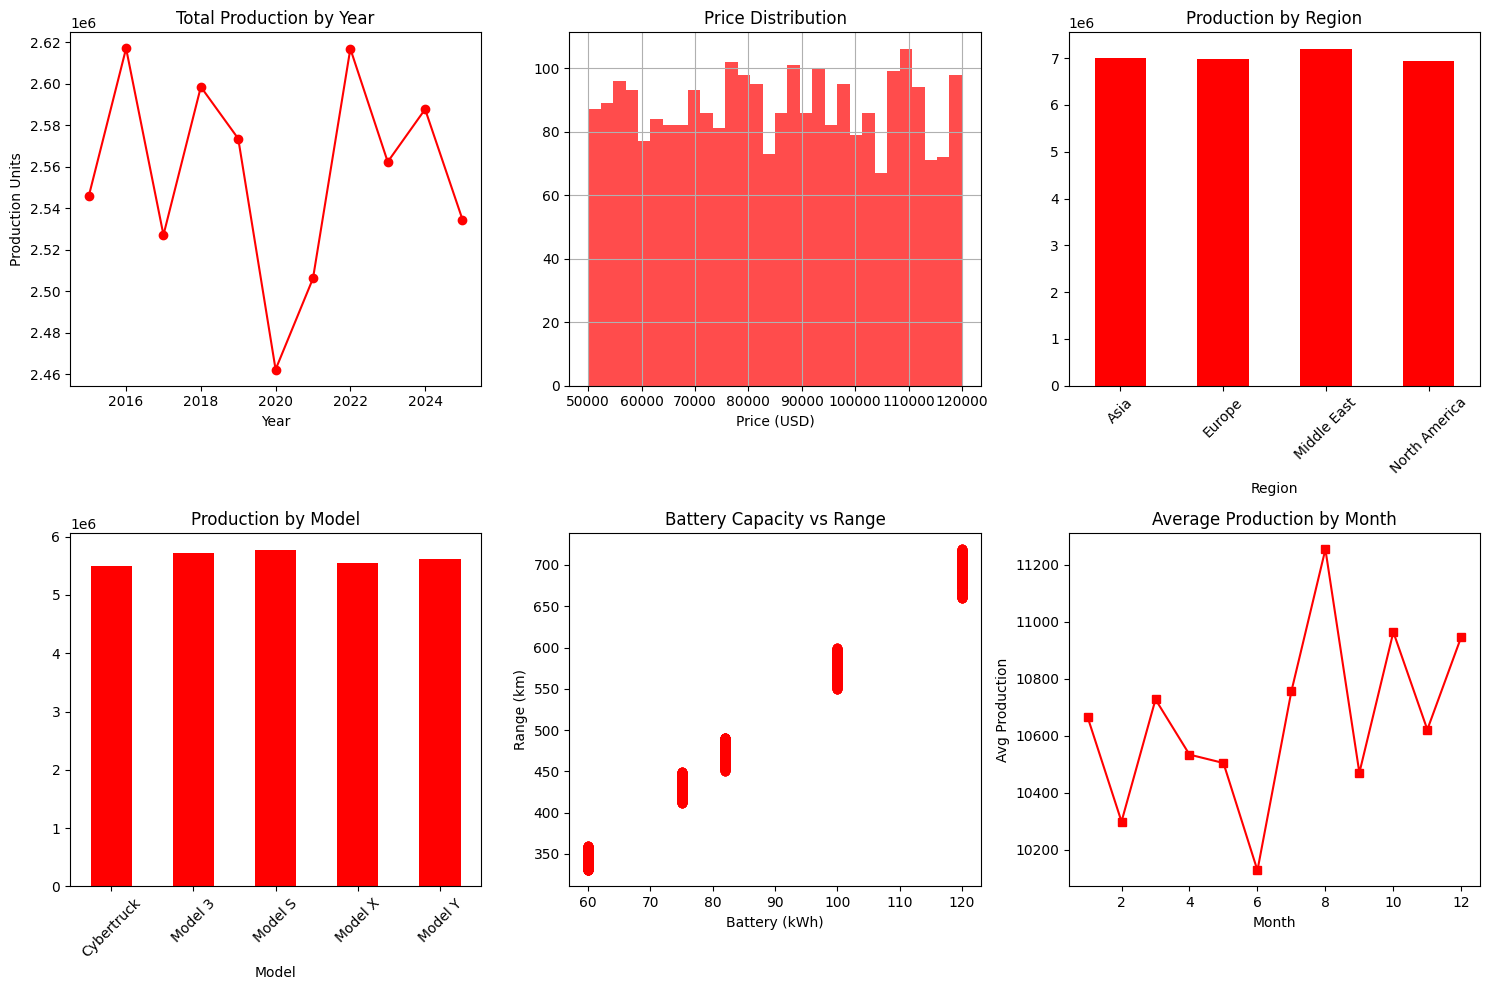

In [26]:
print("Exploratory Data Analysis (EDA):-")

# Check data quality
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# Basic statistics
print("\nNumerical columns stats:")
print(df.describe())

# Simple plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Production trend
df.groupby('Year')['Production_Units'].sum().plot(ax=axes[0,0], marker='o', color='red')
axes[0,0].set_title('Total Production by Year')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Production Units')

# Price distribution
df['Avg_Price_USD'].hist(ax=axes[0,1], bins=30, color='red', alpha=0.7)
axes[0,1].set_title('Price Distribution')
axes[0,1].set_xlabel('Price (USD)')

# Production by region
df.groupby('Region')['Production_Units'].sum().plot(kind='bar', ax=axes[0,2], color='red')
axes[0,2].set_title('Production by Region')
axes[0,2].tick_params(axis='x', rotation=45)

# Production by model
df.groupby('Model')['Production_Units'].sum().plot(kind='bar', ax=axes[1,0], color='red')
axes[1,0].set_title('Production by Model')
axes[1,0].tick_params(axis='x', rotation=45)

# Battery vs Range
axes[1,1].scatter(df['Battery_Capacity_kWh'], df['Range_km'], alpha=0.5, color='red')
axes[1,1].set_title('Battery Capacity vs Range')
axes[1,1].set_xlabel('Battery (kWh)')
axes[1,1].set_ylabel('Range (km)')

# Monthly seasonality
df.groupby('Month')['Production_Units'].mean().plot(ax=axes[1,2], marker='s', color='red')
axes[1,2].set_title('Average Production by Month')
axes[1,2].set_xlabel('Month')
axes[1,2].set_ylabel('Avg Production')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=100)
plt.show()

In [27]:
df_copy = df.copy()

# Encode categorical variables
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_copy['Region_Code'] = le_region.fit_transform(df_copy['Region'])
df_copy['Model_Code'] = le_model.fit_transform(df_copy['Model'])
df_copy['Source_Code'] = le_source.fit_transform(df_copy['Source_Type'])

# Create ratio features
df_copy['Price_per_kWh'] = df_copy['Avg_Price_USD'] / df_copy['Battery_Capacity_kWh']
df_copy['Range_per_kWh'] = df_copy['Range_km'] / df_copy['Battery_Capacity_kWh']
df_copy['Production_Delivery_Ratio'] = df_copy['Production_Units'] / df_copy['Estimated_Deliveries']

# Time features
df_copy['Quarter'] = df_copy['Month'].apply(lambda x: (x-1)//3 + 1)
df_copy['Is_Year_End'] = (df_copy['Month'] == 12).astype(int)

# Model age
launch_years = {'Model S': 2012, 'Model X': 2015, 'Model 3': 2017, 'Model Y': 2020, 'Cybertruck': 2023}
df_copy['Model_Age'] = df_copy.apply(lambda row: row['Year'] - launch_years.get(row['Model'], 2015), axis=1)

print(f"Features created: {df_copy.shape[1]} total columns")

Features created: 21 total columns


In [28]:
print("MODEL PREPARATION:-")

# Features (X)
feature_cols = [
    'Year', 'Month', 'Quarter', 'Model_Age', 'Is_Year_End',
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Charging_Stations',
    'Price_per_kWh', 'Range_per_kWh', 'Production_Delivery_Ratio',
    'Region_Code', 'Model_Code', 'Source_Code'
]

X = df_copy[feature_cols]
y = df_copy['Production_Units']

print(f"Features used: {len(feature_cols)}")
print(f"Target: Production_Units")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

MODEL PREPARATION:-
Features used: 16
Target: Production_Units
Training set: 2112 samples
Test set: 528 samples


In [31]:
print("MODEL TRAINING:-")

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    results.append({
        'Model': name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'RMSE': test_rmse,
        'MAE': test_mae
    })

    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  RMSE: {test_rmse:,.0f}")
    print(f"  MAE: {test_mae:,.0f}")

# Results DataFrame
results_df = pd.DataFrame(results)
print("\n")
print("MODEL COMPARISON:-" + "\n")
print(results_df.to_string(index=False))

# Best model
best_model = results_df.loc[results_df['Test R²'].idxmax(), 'Model']
best_r2 = results_df['Test R²'].max()
print(f"\nBest Model: {best_model} (R² = {best_r2:.4f})")

MODEL TRAINING:-

Training Linear Regression...
  Train R²: 0.9431
  Test R²: 0.9414
  RMSE: 1,006
  MAE: 706

Training Ridge...
  Train R²: 0.9431
  Test R²: 0.9413
  RMSE: 1,007
  MAE: 707

Training Lasso...
  Train R²: 0.9431
  Test R²: 0.9412
  RMSE: 1,008
  MAE: 707

Training Random Forest...
  Train R²: 0.9986
  Test R²: 0.9935
  RMSE: 335
  MAE: 248

Training XGBoost...
  Train R²: 0.9996
  Test R²: 0.9973
  RMSE: 218
  MAE: 166


MODEL COMPARISON:-

            Model  Train R²  Test R²        RMSE        MAE
Linear Regression  0.943117 0.941442 1005.861741 706.370707
            Ridge  0.943096 0.941306 1007.025097 706.887535
            Lasso  0.943051 0.941158 1008.297205 707.418821
    Random Forest  0.998647 0.993514  334.768603 247.524735
          XGBoost  0.999635 0.997254  217.836109 166.066849

Best Model: XGBoost (R² = 0.9973)


FEATURE IMPORTANCE:-

Top 10 Most Important Features:
                  Feature  Importance
           CO2_Saved_tons    0.602338
     Battery_Capacity_kWh    0.255304
                 Range_km    0.125352
Production_Delivery_Ratio    0.010210
              Source_Code    0.002375
            Range_per_kWh    0.001002
            Price_per_kWh    0.000699
               Model_Code    0.000610
            Avg_Price_USD    0.000496
        Charging_Stations    0.000434


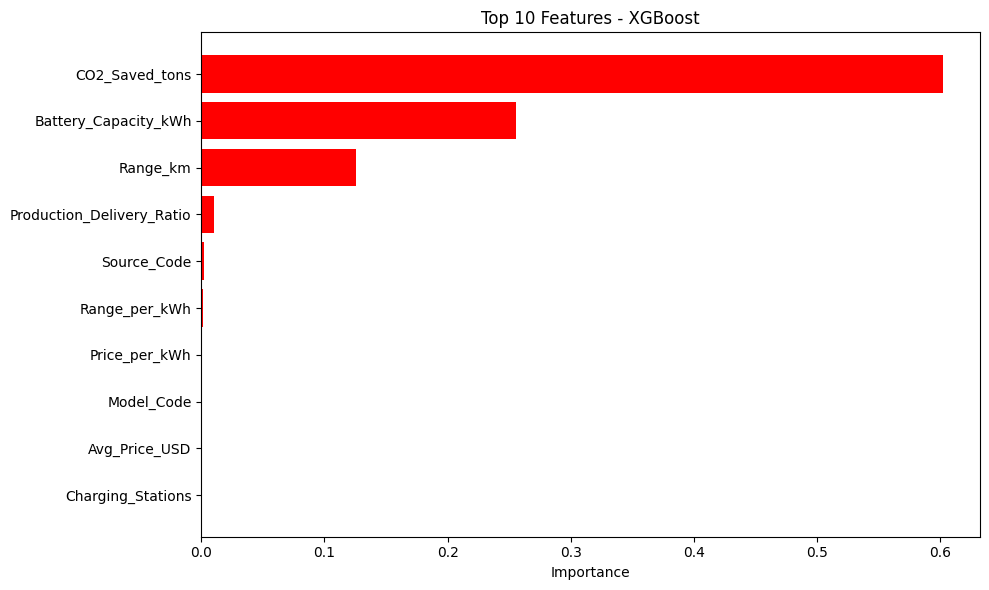

In [32]:
if best_model in ['Random Forest', 'XGBoost']:
    print("FEATURE IMPORTANCE:-")

    if best_model == 'Random Forest':
        best_rf = RandomForestRegressor(n_estimators=100, random_state=42)
        best_rf.fit(X_train, y_train)
        importances = best_rf.feature_importances_
    else:
        best_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
        best_xgb.fit(X_train, y_train)
        importances = best_xgb.feature_importances_

    # Create importance dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df.head(10)['Feature'], importance_df.head(10)['Importance'], color='red')
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100)
    plt.show()

In [33]:
print("SAVING PREDICTIONS:-")

if best_model == 'Linear Regression':
    final_model = LinearRegression()
elif best_model == 'Ridge':
    final_model = Ridge(alpha=1.0)
elif best_model == 'Lasso':
    final_model = Lasso(alpha=1.0)
elif best_model == 'Random Forest':
    final_model = RandomForestRegressor(n_estimators=100, random_state=42)
else:
    final_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_final,
    'Error': y_test.values - y_pred_final,
    'Error_Percentage': np.abs((y_test.values - y_pred_final) / y_test.values) * 100
})

print(predictions_df.head(10))
print(f"\nAverage Error: {predictions_df['Error_Percentage'].mean():.2f}%")

# Save to CSV
predictions_df.to_csv('production_predictions.csv', index=False)
print("\nSaved: production_predictions.csv")

SAVING PREDICTIONS:-
   Actual     Predicted       Error  Error_Percentage
0    7968   7839.330078  128.669922          1.614833
1   10117  10062.900391   54.099609          0.534740
2    9355   9063.421875  291.578125          3.116816
3   10171  10047.353516  123.646484          1.215677
4    9536   9516.281250   19.718750          0.206782
5   12445  12112.982422  332.017578          2.667879
6   15440  15506.779297  -66.779297          0.432508
7   15346  15059.217773  286.782227          1.868775
8   10757  10812.624023  -55.624023          0.517096
9    8425   8272.806641  152.193359          1.806449

Average Error: 2.02%

Saved: production_predictions.csv


In [34]:
print("TIME SERIES FORECASTING:-" + "\n")

# Aggregate monthly production
ts_data = df.groupby(['Year', 'Month'])['Production_Units'].sum().reset_index()
ts_data['Date'] = pd.to_datetime(ts_data[['Year', 'Month']].assign(day=1))
ts_data = ts_data.set_index('Date')

# Simple moving average forecast
last_year_avg = ts_data['Production_Units'].tail(12).mean()
forecast_next_12 = [last_year_avg] * 12

print(f"Next 12 months forecasted avg: {last_year_avg:,.0f} units/month")

TIME SERIES FORECASTING:-

Next 12 months forecasted avg: 211,210 units/month


In [35]:
print(f"""
PIPELINE COMPLETED SUCCESSFULLY

DATA SUMMARY:
   • Total records: {len(df):,}
   • Features used: {len(feature_cols)}
   • Target: Production Units

MODEL PERFORMANCE:
   • Best Model: {best_model}
   • Test R² Score: {best_r2:.4f}
   • RMSE: {results_df.loc[results_df['Model']==best_model, 'RMSE'].values[0]:,.0f}
   • MAE: {results_df.loc[results_df['Model']==best_model, 'MAE'].values[0]:,.0f}

KEY INSIGHTS:
   • Production peaks in month: {df.groupby('Month')['Production_Units'].sum().idxmax()}
   • Best performing region: {df.groupby('Region')['Production_Units'].sum().idxmax()}
   • Most produced model: {df.groupby('Model')['Production_Units'].sum().idxmax()}
""")



PIPELINE COMPLETED SUCCESSFULLY

DATA SUMMARY:
   • Total records: 2,640
   • Features used: 16
   • Target: Production Units

MODEL PERFORMANCE:
   • Best Model: XGBoost
   • Test R² Score: 0.9973
   • RMSE: 218
   • MAE: 166

KEY INSIGHTS:
   • Production peaks in month: 8
   • Best performing region: Middle East
   • Most produced model: Model S

